# 📦 EDA Senior – Item Properties
**Proyecto:** NexusDataCo | **Gráficas:** 7

> Evalúa la riqueza semántica del catálogo: densidad de atributos, cardinalidad,
frecuencia temporal de actualizaciones y potencial para Filtrado Basado en Contenido.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
from src.config import *
from src.data_cleaning import load_item_properties, summarize_dataframe
from src.viz import setup_style
setup_style('rocket')

SAMPLE = 1_000_000   # muestra para velocidad
df = load_item_properties(ITEM_PROPS_PART1, ITEM_PROPS_PART2, sample_n=SAMPLE)
summarize_dataframe(df, f'Item Properties (sample={SAMPLE:,})')


  RESUMEN: Item Properties (sample=1,000,000)
  Filas    :    2,000,000
  Columnas :            4

  TIPOS DE DATOS Y VALORES NULOS:
                     Tipo  Nulos  % Nulos
timestamp  datetime64[ns]      0      0.0
itemid              int64      0      0.0
property           object      0      0.0
value              object      0      0.0

  Filas duplicadas: 0 (0.00%)



## 1 · Top 20 Propiedades Más Frecuentes

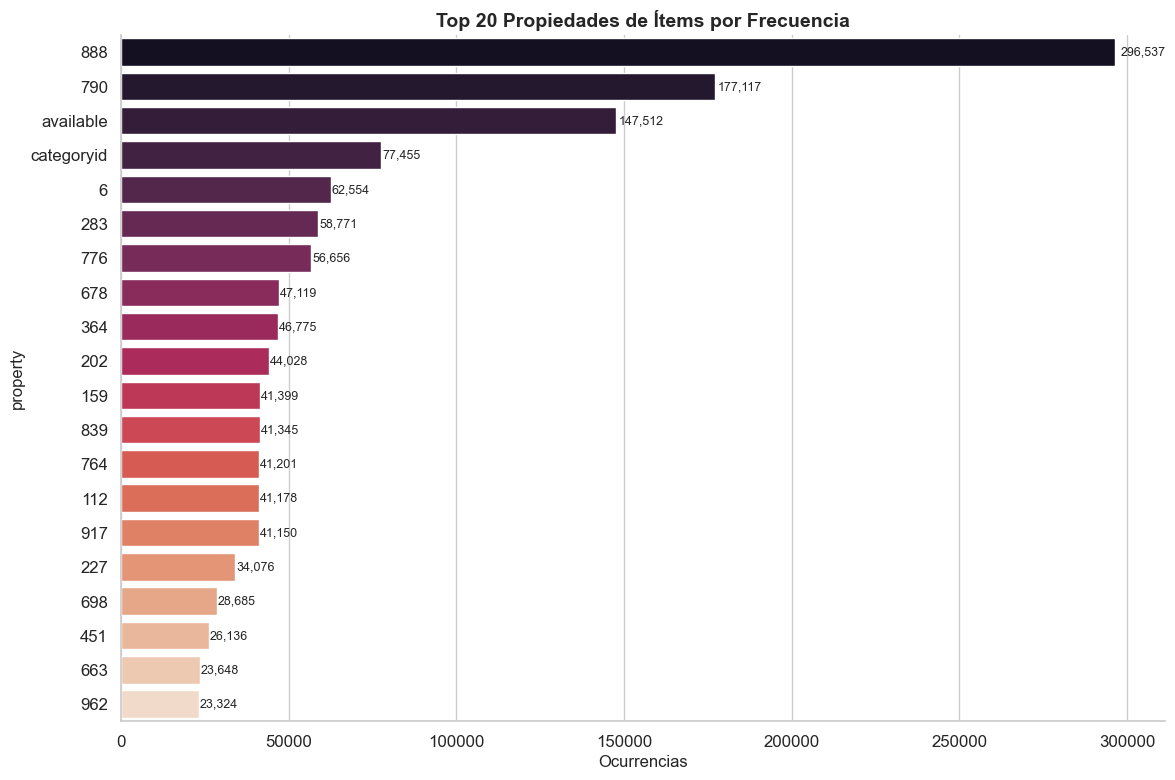

In [2]:
# ── Gráfica 1: barplot horizontal de propiedades ──
top_props = df['property'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(x=top_props.values, y=top_props.index, palette='rocket', ax=ax)
ax.set_title('Top 20 Propiedades de Ítems por Frecuencia', fontweight='bold')
ax.set_xlabel('Ocurrencias')
for bar, v in zip(ax.patches, top_props.values):
    ax.text(v*1.005, bar.get_y()+bar.get_height()/2, f'{v:,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

## 2 · Cardinalidad de Propiedades

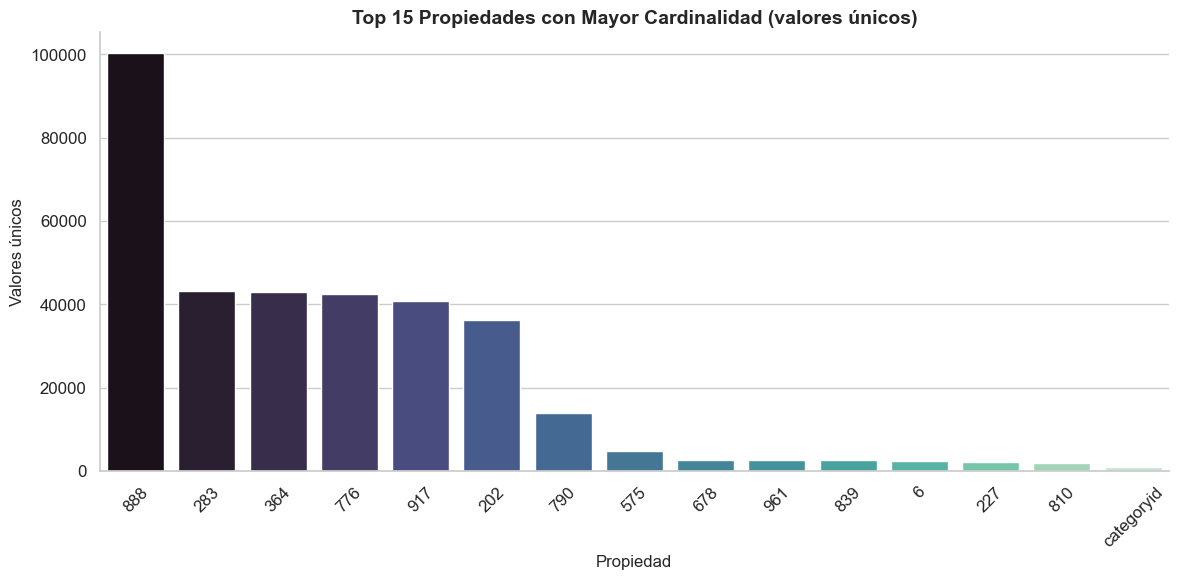

In [3]:
# ── Gráfica 2: cardinalidad por propiedad ──
cardinality = df.groupby('property')['value'].nunique().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=cardinality.index, y=cardinality.values, palette='mako', ax=ax)
ax.set_title('Top 15 Propiedades con Mayor Cardinalidad (valores únicos)', fontweight='bold')
ax.set_ylabel('Valores únicos'); ax.set_xlabel('Propiedad')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 3 · Cobertura de Atributos por Ítem

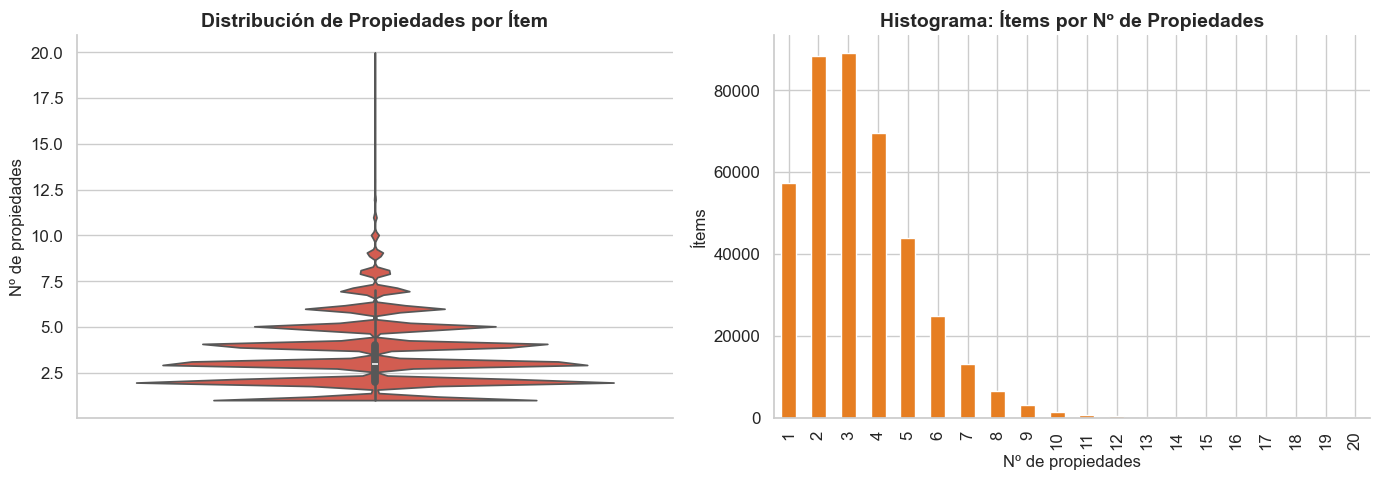

Ítem con más propiedades   : 20 propiedades
Ítems con 1 sola propiedad : 57,339
Mediana de propiedades/ítem: 3.0


In [4]:
# Número de propiedades distintas por ítem
coverage = df.groupby('itemid')['property'].nunique()

# ── Gráfica 3: violín de cobertura ──
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.violinplot(y=coverage, ax=axes[0], color='#e74c3c', cut=0)
axes[0].set_title('Distribución de Propiedades por Ítem', fontweight='bold')
axes[0].set_ylabel('Nº de propiedades')
coverage.value_counts().sort_index().head(30).plot(kind='bar', ax=axes[1], color='#e67e22')
axes[1].set_title('Histograma: Ítems por Nº de Propiedades', fontweight='bold')
axes[1].set_xlabel('Nº de propiedades'); axes[1].set_ylabel('Ítems')
plt.tight_layout(); plt.show()

print(f'Ítem con más propiedades   : {coverage.max()} propiedades')
print(f'Ítems con 1 sola propiedad : {(coverage==1).sum():,}')
print(f'Mediana de propiedades/ítem: {coverage.median():.1f}')

## 4 · Actualización Temporal de Propiedades

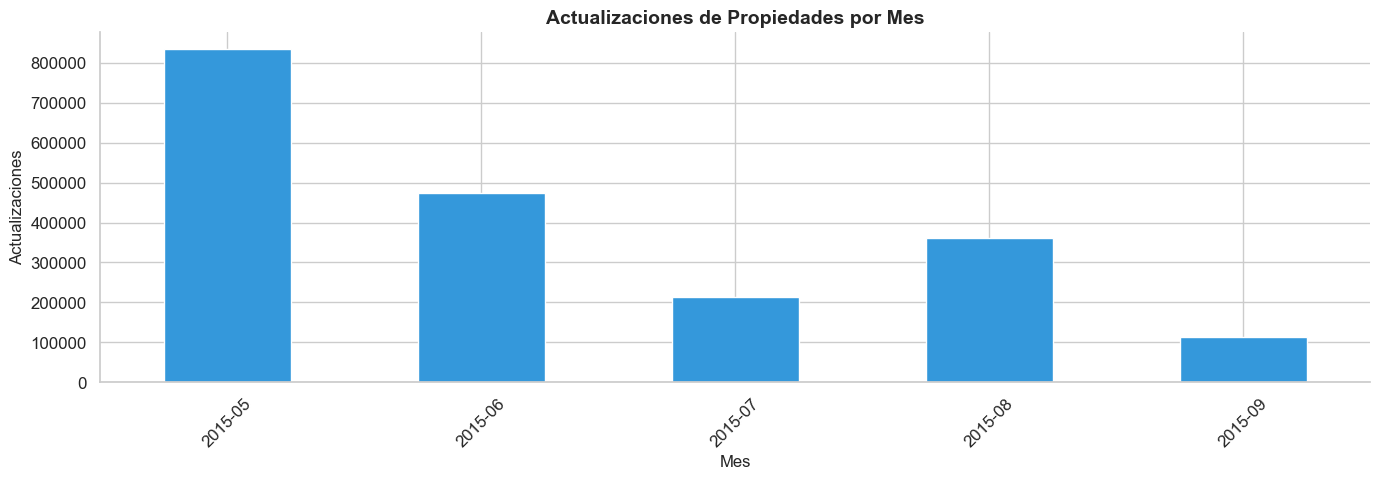

In [5]:
df2 = df.dropna(subset=['timestamp']).copy()
df2['month'] = df2['timestamp'].dt.to_period('M').astype(str)

# ── Gráfica 5: actualizaciones por mes ──
monthly = df2.groupby('month').size()
fig, ax = plt.subplots(figsize=(14,5))
monthly.plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')
ax.set_title('Actualizaciones de Propiedades por Mes', fontweight='bold')
ax.set_xlabel('Mes'); ax.set_ylabel('Actualizaciones')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## 5 · Análisis de Valores Numéricos vs Categóricos

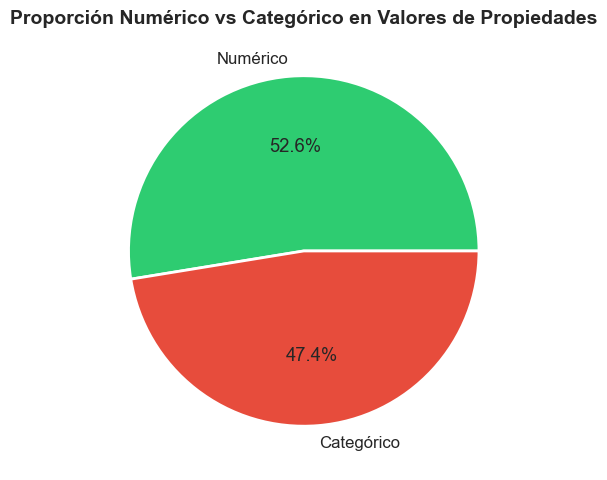

In [6]:
def is_numeric(v):
    try: float(str(v)); return True
    except: return False

sample = df.sample(min(100_000, len(df)), random_state=42)
sample['value_type'] = sample['value'].apply(lambda v: 'Numérico' if is_numeric(v) else 'Categórico')

# ── Gráfica 6: tipo de valor por propiedad ──
type_counts = sample['value_type'].value_counts()
fig, ax = plt.subplots(figsize=(7,5))
ax.pie(type_counts.values, labels=type_counts.index,
       autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Proporción Numérico vs Categórico en Valores de Propiedades', fontweight='bold')
plt.tight_layout(); plt.show()

## 6 · Ítems Más Actualizados

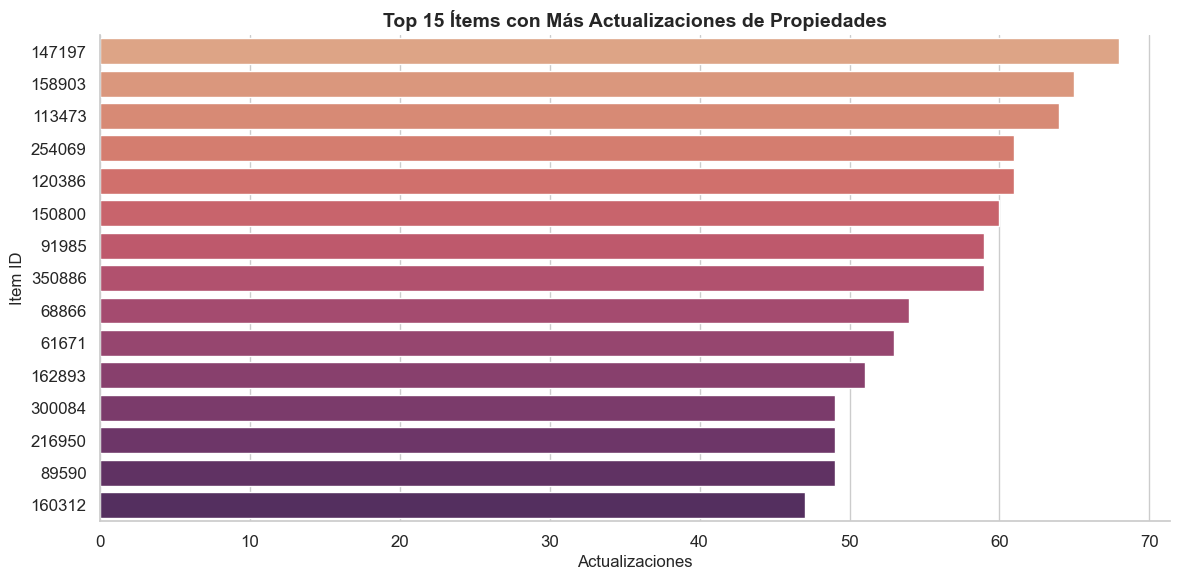

In [7]:
# ── Gráfica 7: top 15 ítems con más actualizaciones ──
top_updated = df.groupby('itemid').size().sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(12,6))
sns.barplot(x=top_updated.values, y=top_updated.index.astype(str), palette='flare', ax=ax)
ax.set_title('Top 15 Ítems con Más Actualizaciones de Propiedades', fontweight='bold')
ax.set_xlabel('Actualizaciones'); ax.set_ylabel('Item ID')
plt.tight_layout(); plt.show()

## 7 · Resumen para Modelado

| Hallazgo | Implicación |
|----------|-------------|
| Propiedades muy frecuentes existen | Usar como features en CBF |
| Alta cardinalidad en algunas props | Aplicar feature hashing o embeddings |
| Cobertura variable por ítem | Manejo de matrices sparse |
| Actualizaciones temporales | Feature engineering de recencia |